In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')


 All libraries imported successfully


In [2]:

df = pd.read_csv('../data/synthetic_data/historical_dispatch.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (500, 22)

Columns: ['dispatch_id', 'product', 'wagon_type', 'num_wagons', 'quantity_tonnes', 'fill_percentage', 'destination_id', 'destination_city', 'distance_km', 'planned_dispatch_date', 'actual_dispatch_date', 'delay_days', 'is_delayed', 'pending_orders_count', 'inventory_level', 'dock_utilization', 'is_month_end', 'day_of_week', 'month', 'demurrage_cost', 'freight_cost', 'total_cost']

First 5 rows:


,dispatch_id,product,wagon_type,num_wagons,quantity_tonnes,fill_percentage,destination_id,destination_city,distance_km,planned_dispatch_date,...,is_delayed,pending_orders_count,inventory_level,dock_utilization,is_month_end,day_of_week,month,demurrage_cost,freight_cost,total_cost
0,DISP2000,Wire Rod,BCN,42,1988.20,86.07,CMO07,Pune,1750,2023-04-08,...,0,11,0.415,0.772,0,5,4,0,4175220.0,4175220.0
1,DISP2001,Semis,BOBYN,58,3192.17,91.73,CMO01,Delhi,1200,2023-10-14,...,1,32,0.584,0.909,0,5,10,4350000,4596724.8,8946724.8
2,DISP2002,HR Coil,BOBYN,43,2384.08,92.41,CMO02,Mumbai,1800,2023-09-03,...,1,36,0.757,0.793,0,6,9,645000,5149612.8,5794612.8
3,DISP2003,TMT Bar,BCN,52,2402.04,83.99,CMO07,Pune,1750,2023-11-29,...,0,50,0.447,0.552,1,2,11,0,5044284.0,5044284.0
4,DISP2004,Wire Rod,BLC,50,3020.33,97.43,CMO01,Delhi,1200,2023-07-09,...,1,45,0.531,0.694,0,6,7,750000,4349275.2,5099275.2


In [ ]:

print(" Data Info ")
print(df.info())

print("\n Missing Values ")
print(df.isnull().sum())

print("\n Delay Distribution ")
print(df['is_delayed'].value_counts())
print(f"\nDelay Rate: {df['is_delayed'].mean()*100:.1f}%")

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dispatch_id            500 non-null    object 
 1   product                500 non-null    object 
 2   wagon_type             500 non-null    object 
 3   num_wagons             500 non-null    int64  
 4   quantity_tonnes        500 non-null    float64
 5   fill_percentage        500 non-null    float64
 6   destination_id         500 non-null    object 
 7   destination_city       500 non-null    object 
 8   distance_km            500 non-null    int64  
 9   planned_dispatch_date  500 non-null    object 
 10  actual_dispatch_date   500 non-null    object 
 11  delay_days             500 non-null    int64  
 12  is_delayed             500 non-null    int64  
 13  pending_orders_count   500 non-null    int64  
 14  inventory_level        500 non-null    f

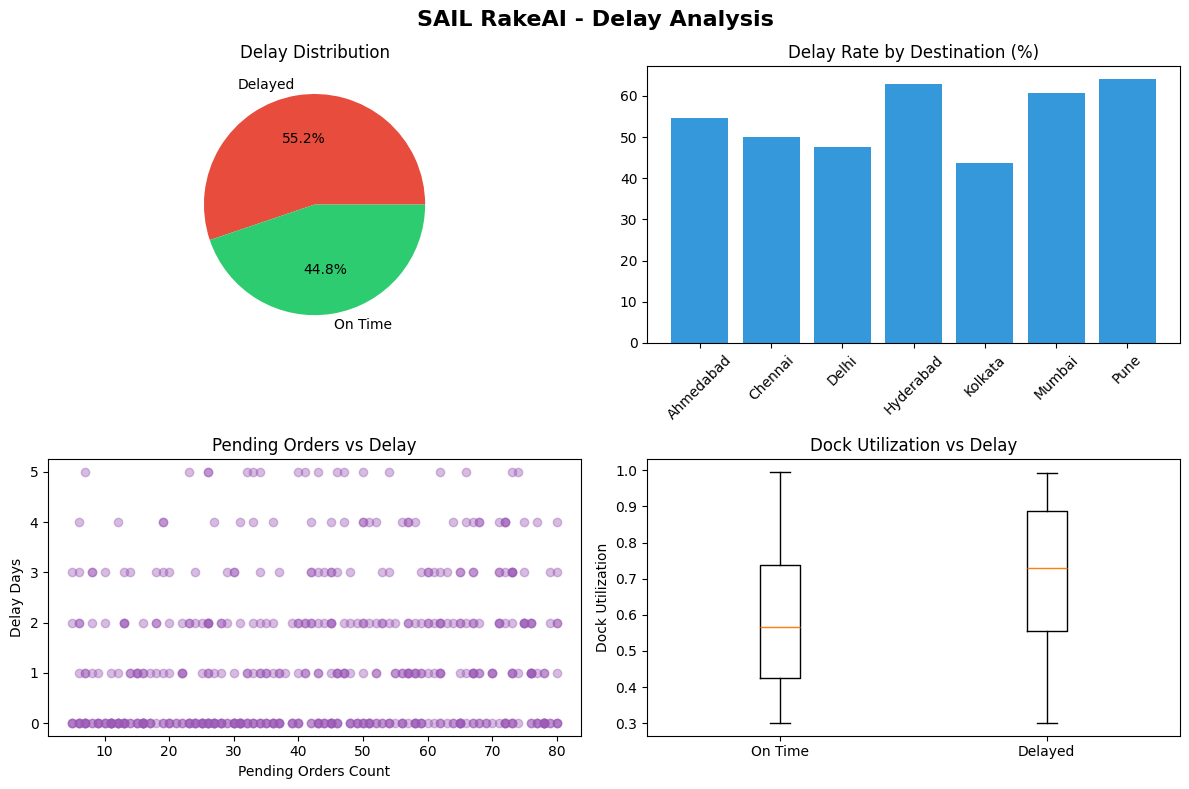

 Plot saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SAIL RakeAI - Delay Analysis', fontsize=16, fontweight='bold')

axes[0,0].pie(df['is_delayed'].value_counts(), 
              labels=['Delayed', 'On Time'], 
              autopct='%1.1f%%',
              colors=['#e74c3c', '#2ecc71'])
axes[0,0].set_title('Delay Distribution')

delay_by_dest = df.groupby('destination_city')['is_delayed'].mean() * 100
axes[0,1].bar(delay_by_dest.index, delay_by_dest.values, color='#3498db')
axes[0,1].set_title('Delay Rate by Destination (%)')
axes[0,1].tick_params(axis='x', rotation=45)


axes[1,0].scatter(df['pending_orders_count'], df['delay_days'], 
                  alpha=0.4, color='#9b59b6')
axes[1,0].set_xlabel('Pending Orders Count')
axes[1,0].set_ylabel('Delay Days')
axes[1,0].set_title('Pending Orders vs Delay')


axes[1,1].boxplot([df[df['is_delayed']==0]['dock_utilization'],
                   df[df['is_delayed']==1]['dock_utilization']],
                   labels=['On Time', 'Delayed'])
axes[1,1].set_title('Dock Utilization vs Delay')
axes[1,1].set_ylabel('Dock Utilization')

plt.tight_layout()
plt.savefig('../ml/delay_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved")

In [5]:


features = [
    'num_wagons',
    'quantity_tonnes',
    'distance_km',
    'pending_orders_count',
    'inventory_level',
    'dock_utilization',
    'is_month_end',
    'fill_percentage',
    'day_of_week',        
    'month'               
]


le = LabelEncoder()
df['wagon_type_encoded'] = le.fit_transform(df['wagon_type'])
features.append('wagon_type_encoded')


df['destination_encoded'] = le.fit_transform(df['destination_city'])
features.append('destination_encoded')

X = df[features]
y = df['is_delayed']

print(f" Features selected: {len(features)}")
print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")
print(f"\nFeatures used for training:")
for i, f in enumerate(features, 1):
    print(f"   {i}. {f}")

 Features selected: 12
 X shape: (500, 12)
 y shape: (500,)

Features used for training:
   1. num_wagons
   2. quantity_tonnes
   3. distance_km
   4. pending_orders_count
   5. inventory_level
   6. dock_utilization
   7. is_month_end
   8. fill_percentage
   9. day_of_week
   10. month
   11. wagon_type_encoded
   12. destination_encoded


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y 
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f" Testing set:    {X_test.shape[0]} samples")
print(f"\nDelay rate in training: {y_train.mean()*100:.1f}%")
print(f"Delay rate in testing:  {y_test.mean()*100:.1f}%")

Training set:   400 samples
 Testing set:    100 samples

Delay rate in training: 55.2%
Delay rate in testing:  55.0%


In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

print(" Training  model")
xgb_model.fit(X_train, y_train)
print(" Model trained successfully")

y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print(f"\n Predictions made on {len(y_pred)} test samples")

 Training XGBoost model...
 Model trained successfully!

 Predictions made on 100 test samples


    SAIL RakeAI - Delay Prediction Results

 Accuracy:  64.00%
 ROC-AUC:   0.7063

=== Classification Report ===
              precision    recall  f1-score   support

     On Time       0.64      0.47      0.54        45
     Delayed       0.64      0.78      0.70        55

    accuracy                           0.64       100
   macro avg       0.64      0.62      0.62       100
weighted avg       0.64      0.64      0.63       100



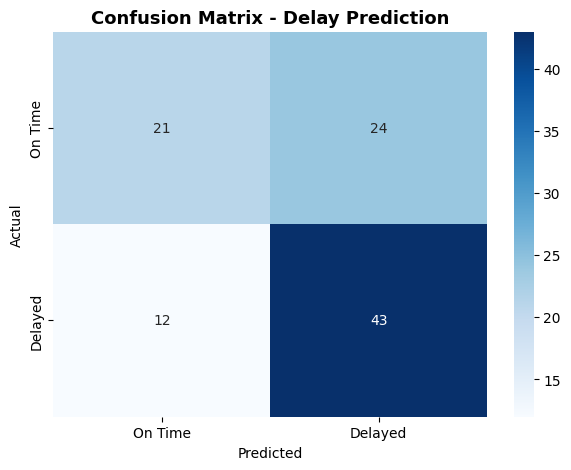

 Confusion matrix saved!


In [ ]:

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print("=" * 45)

print("=" * 45)
print(f"\n Accuracy:  {accuracy*100:.2f}%")
print(f" ROC-AUC:   {roc_auc:.4f}")
print(f"\n Classification Report ")
print(classification_report(y_test, y_pred, 
      target_names=['On Time', 'Delayed']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.title('Confusion Matrix - Delay Prediction', 
          fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('../ml/confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved")

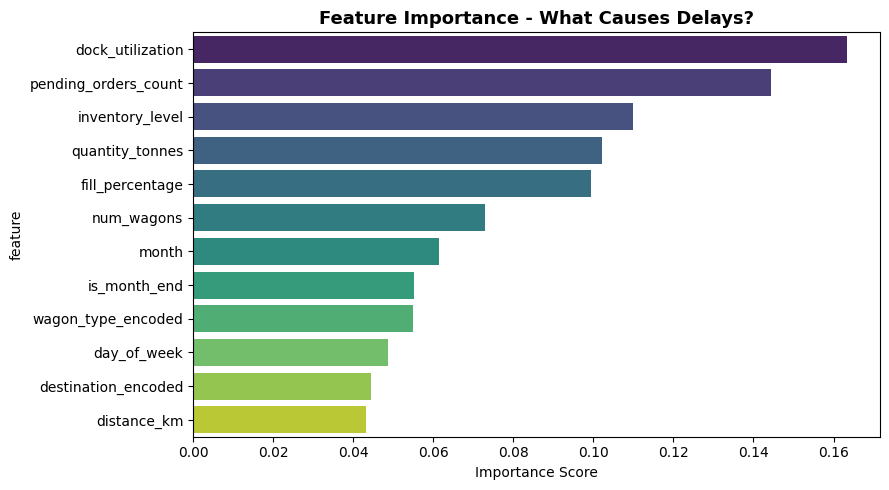


 Top 3 Delay Causes 
   dock_utilization: 0.1634
   pending_orders_count: 0.1445
   inventory_level: 0.1100


In [9]:

importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='importance', y='feature', 
            palette='viridis')
plt.title('Feature Importance - What Causes Delays?',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../ml/feature_importance.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 3 Delay Causes ")
for i, row in importance_df.head(3).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")